Kelin Levine (EID: kel3258)  
May 4, 2026  
COE 311K - Engineering Computation, Spring 2026  
The University of Texas at Austin  
AI was not used in the creation of this report.

# Introduction & System Selection

In this project, I will attempt to use Euler's Backward Method with a Newton-Raphson solver
to solve a stiff ordinary differential equation. I will solve a mechanical system with high
damping, in this case an overdamped spring-mass system. This system describes how the
displacement of a mass on a highly damped spring oscillates as it experiences an external
force. This system is important because in the real world, this model can be applied to systems
such as shock absorbers, vibration dampers, and seismic isolation. This system will be
represented by the following ODE (converted to first-order by assuming $m\to 0m \to 0$):

$$\frac{dx}{dt}=-\frac{k}{c}x+\frac{1}{c}F(t)$$

Where our parameters for stiffness will be:
- $k/c=5000\text{ s}^{-1}$ (very high damping rate)
- $F(t)=10\sin(t)\text{ N}$ (slow external force)
- Initial condition: $x(0)=1\text{ m}$ (displacement of the mass)

Rewritten in standard form:

$$\frac{dx}{dt}=-5000x+0.002\sin(t)$$

# Demonstration of Stiffness

In [1]:
"""Setup Numerical Implementation

This cell must be run before any following numerical implementation. This is to
load the necessary parameters and functions into the kernel. It should not
produce any output by itself.

For convenience, this also includes a function to plot solutions of the ODE.
"""


# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt


# Define the parameters
t_i = 0.0  # Start of interval
t_f = 2.0  # End of interval
x_i = 1.0  # Initial condition of x

h_values_explicit = [0.1]  # Step size (explicit method)
h_values_implicit = [2.0, 0.1, 0.01, 0.001, 0.0001]  # Step sizes (implicit method)


# Define the ODE function
def f(t, x):
    """Function representing the dx/dt ODE"""
    return -5000*x + 0.002*np.sin(t)


# Convenience function for plotting a solution to the ODE
def plot_solution(solver, title, h_values):
    # Configure plot
    plt.title(f'Displacement of Mass Using {title}')
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement (m)')
    plt.grid(True)

    # Run the solver, plot and record all solutions
    all_values = []
    for h in h_values:
        values = solver(f, x_i, t_i, t_f, h)
        plt.plot(values[0], values[1], label=f'Step size: h={h}')
        all_values.append(values)

    # Finish plotting
    plt.legend(loc='upper left')

    # Return solutions (for optional processing)
    return all_values


In [2]:
"""Euler's Forward Method

Solve the first-order differential equation using Euler's Forward Method.

This cell runs after the 'Setup Numerical Implementation' cell in the kernel.
"""


# Euler's Forward Method Implementation
def forward_euler(f, x_i, t_i, t_f, h):
    # Create arrays to store t and x values
    t_values = np.arange(t_i, t_f + h, h)
    x_values = np.zeros(len(t_values))

    # Set initial condition
    x_values[0] = x_i

    # Euler's Forward Method step loop
    for i in range(1, len(t_values)):
        # Current values
        t_n = t_values[i - 1]
        x_n = x_values[i - 1]
        # Update solution
        x_values[i] = x_n + h * f(t_n, x_n)
    return t_values, x_values


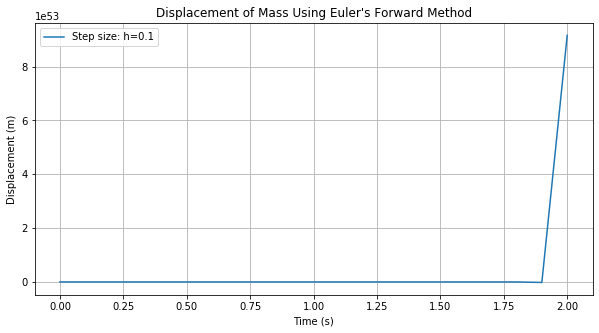

In [3]:
"""Plot Euler's Forward Method

Plot the solution of the differential equation using Euler's Forward Method.

This cell runs after the 'Euler's Forward Method' cell in the kernel.
"""


# Setup plot
plt.figure(figsize=(10, 5))

# Solve and plot solution
plot_solution(forward_euler, "Euler's Forward Method", h_values_explicit)

# Show plot
plt.show()


Euler's Forward Method is an explicit numerical method. Explicit numerical
methods struggle to solve stiff equations because some parts of the solution
change very fast relative to the size of the simulation interval, so the
method will become unstable unless step size is extremely small. As shown
above, with a reasonable step size ($h=0.1$), Euler's Forward Method becomes
very unstable, showing displacement rapidly rising to unreasonable values as
time increases. Because small step sizes incur a high computational cost,
solving stiff equations (such as this one) with explicit methods can be impractical.

This equation is stiff because the system responds in about 0.2 milliseconds,
but force varies over seconds. We can calculate the local stiffness of our
equation at any point using the magnitude of its partial derivative with
respect to $x$:

$$\left|\frac{\partial}{\partial x}\left[-5000x+0.002\sin(t)\right]\right|=5000$$

Since all variables are eliminated in this process, the stiffness ratio for
this equation is a constant $5000$. This matches the given stiffness ratio:
$5\times10^3=5000$.

Considering that the system responds initially in about 0.2 milliseconds
(0.0002 seconds), a step size that achieves stability with Euler's Forward
Method would have to capture this period. To have 10 steps within this period
would require a step size of $h=\frac{0.0002}{10}=0.00002$ seconds. To simulate
the entire interval at this step size would require 50,000 steps per second of
simulated time. This is unreasonably computationally expensive for a system that
settles slowly over several seconds: all of the time after the initial 0.2ms
response experiences relatively slow change that would remain stable with a much
higher step size, so after the initial response, most of this work is redundant
and wasteful.

# Mathematical Setup

The Newton-Raphson update formula is of the form:

$$x_{i+1}=x_i-\frac{g(x_i)}{g'(x_i)}$$

Where $x_i$ is the previous guess for displacement at the next step, $x_{i+1}$
is the next guess after the iteration, and $g$ is the residual function.

The residual function $g(x_{n+1})$ for Newton-Raphson with Euler's Backwards
Method is of the form:

$$g(x_{n+1})=x_{n+1} - x_n - hf(t_{n+1}, x_{n+1})$$

Where $x_n$ is the displacement at the previous step, $x_{n+1}$ is the
displacement at the next step, $t_{n+1}$ is the time at the next step, $h$
is the step size, and $f(t, x)=\frac{dx}{dt}$.

For our equation, the residual function is:

$$g(x_{n+1})=x_{n+1} - x_n - h(-5000x_{n+1} + 0.002\sin(t_{n+1}))$$

From this, we can analytically take the derivative of the residual function:

$$g'(x_{n+1})=1 + 5000h$$

Finally, using the residual function and its derivative, we can write the
complete Newton-Raphson update formula for this specific problem:

$$x_{i+1}=x_i-\frac{x_i - x_n - h(-5000x_i + 0.002\sin(t_{n+1}))}{1 + 5000h}$$

This can be rewritten further to eliminate $x_i$:

$$x_{i+1}=\frac{x_n + 0.002h\sin(t_{n+1})}{1 + 5000h}$$

Interestingly, because the update formula does not depend on the previous guess,
this means that the Newton-Raphson algorithm will always find the same solution in
every iteration. This makes multiple iterations (and the initial guess) redundant.

# Implementation

In [4]:
"""Newton-Raphson Root-Finding Algorithm

Implementations of Newton-Raphson Method to predict displacement at the next
time step using the residual function.

This includes three implementations of Newton-Raphson: a general version that
takes any residual function, an "auto" version that implements the residual
function derived in 'Mathematical Setup' into the general implementation, and an
"auto optimized" version for this residual function with a unique implementation
to take advantage of its simplified update formula.

The residual function is programmed into relevant implementations directly and
is NOT based on the ODE function in the 'Setup Numerical Implementation' cell.

This cell runs after the 'Setup Numerical Implementation' cell in the kernel.
"""


# Newton-Raphson Implementation
def newton_raphson(g, dg, x_i, tol=1e-6, max_iter=20):
    # Set initial guess
    x = x_i
    # Newton-Raphson iteration loop
    for i in range(max_iter):
        # Update guess using Newton-Raphson formula
        g_val = g(x)
        x_new = x - g_val / dg(x)
        # Finish if residual is within tolerance
        if abs(g_val) < tol:
            return x_new, i + 1
        x = x_new
    # Failure: residual was never within tolerance
    return None, max_iter


def gen_g(t_n1, x_n, h):
    """Generates an anonymous function representing g(x_n+1)."""
    phi1 = 1.0 + 5000.0*h
    phi2 = x_n + 0.002*h*np.sin(t_n1)
    return lambda x_n1: phi1*x_n1 - phi2


def gen_dg(h):
    """Generates an anonymous function representing g'(x_n+1)."""
    phi = 1.0 + 5000.0*h
    return lambda x_n1: phi


# Newton-Raphson (for the specific system's residual function)
def newton_raphson_auto(t_n1, x_n, h, **kwargs):
    # Obtain residual function
    g = gen_g(t_n1, x_n, h)
    dg = gen_dg(h)
    # Newton-Raphson (using current value as initial guess)
    return newton_raphson(g, dg, x_n, **kwargs)


# Newton-Raphson (for the specific system's residual function, optimized)
def newton_raphson_auto_optimized(t_n1, x_n, h):
    # Iterating is redundant because previous guess is not used by formula
    x_new = (x_n + 0.002*h*np.sin(t_n1)) / (1 + 5000*h)
    return x_new, 1


In [5]:
"""Euler's Backward Method with Newton-Raphson

Solve the first-order differential equation using Euler's Backward Method with
Newton-Raphson to solve the residual function.

This cell runs after the 'Newton-Raphson Root-Finding Algorithm' cell in the
kernel.
"""


# Euler's Backward Method Implementation
def backward_euler(f, x_i, t_i, t_f, h, nr=newton_raphson_auto):
    # Create arrays to store t and x values
    t_values = np.arange(t_i, t_f + h, h)
    x_values = np.zeros_like(t_values)
    iterations = np.zeros(t_values.size-1)

    # Set initial condition
    x_values[0] = x_i

    # Euler's Backward Method step loop
    for i in range(1, len(t_values)):
        # Current values
        t_n1 = t_values[i]
        x_n = x_values[i - 1]
        # Update solution
        x_n1, max_iter = nr(t_n1, x_n, h)
        # Record values
        if x_n1 is None:
            print(f"Warning: failed to find roots for t={t_n1} !")
        x_values[i] = x_n1
        iterations[i-1] = max_iter
    return t_values, x_values, iterations


# Optional: use the optimized NR implementation
# - Both give the same value for x_n1; default may have greater truncation error
# - Default may complete in 1 or 2 iters; optimized always completes in 1
def backward_euler_optimized(f, x_i, t_i, t_f, h):
    return backward_euler(f, x_i, t_i, t_f, h, nr=newton_raphson_auto_optimized)


# Results & Analysis

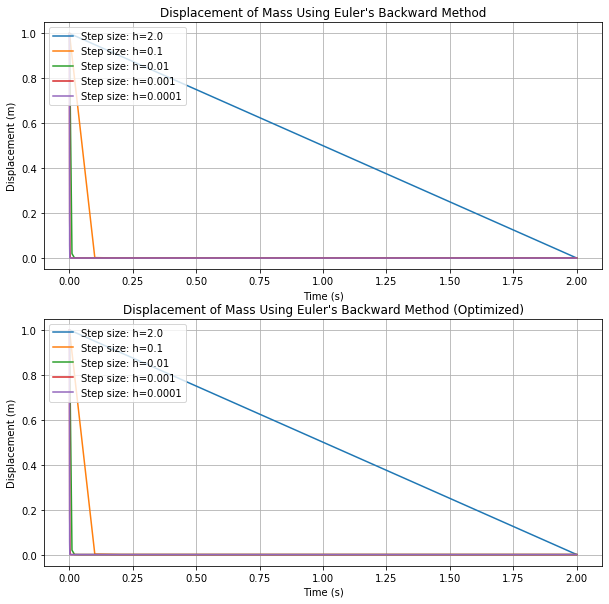

Stats of the solutions using the full non-optimized Newton-Raphson solver:

Solution of step size h=2.0:
Total number of time steps: 1
Average Newton-Raphson iterations per step: 2.0
Total number of Newton-Raphson function evaluations: 2.0

Solution of step size h=0.1:
Total number of time steps: 20
Average Newton-Raphson iterations per step: 1.95
Total number of Newton-Raphson function evaluations: 39.0

Solution of step size h=0.01:
Total number of time steps: 200
Average Newton-Raphson iterations per step: 1.025
Total number of Newton-Raphson function evaluations: 205.0

Solution of step size h=0.001:
Total number of time steps: 2000
Average Newton-Raphson iterations per step: 1.0045
Total number of Newton-Raphson function evaluations: 2009.0

Solution of step size h=0.0001:
Total number of time steps: 20000
Average Newton-Raphson iterations per step: 1.00165
Total number of Newton-Raphson function evaluations: 20033.0


In [6]:
"""Plot Euler's Backward Method with Newton-Raphson

Plot the solution of the differential equation using Euler's Backward Method
with Newton-Raphson to solve the residual function.

This cell runs after the 'Euler's Backward Method with Newton-Raphson' cell in
the kernel.
"""


# Setup plot
plt.figure(figsize=(10, 10))

# Solve and plot solutions
plt.subplot(2, 1, 1)
values_implicit = plot_solution(backward_euler, "Euler's Backward Method", h_values_implicit)
plt.subplot(2, 1, 2)
plot_solution(backward_euler_optimized, "Euler's Backward Method (Optimized)", h_values_implicit)

# Show plot
plt.show()

# Report stats
num_timesteps = [len(v[2]) for v in values_implicit]
avg_iters = [np.mean(v[2]) for v in values_implicit]
num_funcs = [sum(v[2]) for v in values_implicit]
print("Stats of the solutions using the full non-optimized Newton-Raphson solver:")
for i, h in enumerate(h_values_implicit):
    print(f"\nSolution of step size h={h}:")
    print("Total number of time steps:", num_timesteps[i])
    print("Average Newton-Raphson iterations per step:", avg_iters[i])
    print("Total number of Newton-Raphson function evaluations:", num_funcs[i])


## Step Size Comparison

The maximum stable step size for Euler's Forward Method is approximately
$h=0.00002$. Euler's Backward Method can handle much larger step sizes:
it remains stable all the way up to $h=2.0$, which is the largest possible
step size on the simulation interval shown above.

## Convergence Behavior

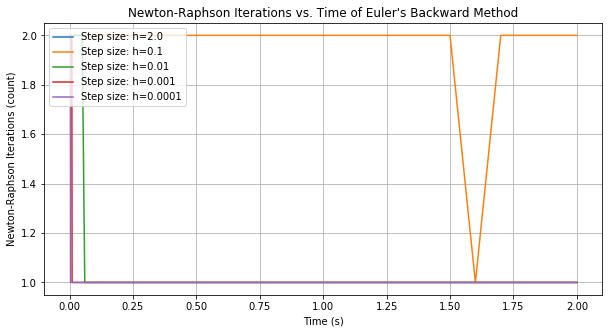

In [7]:
"""Plot Newton-Raphson Iterations vs. Time

Further analyze the performance of the solutions of the differential equation
using Euler's Backward Method and Newton-Raphson by plotting the number of
Newton-Raphson iterations vs. time.

This cell runs after the 'Plot Euler's Backward Method with Newton-Raphson' cell
in the kernel.
"""


# Setup plot
plt.figure(figsize=(10, 5))
plt.title("Newton-Raphson Iterations vs. Time of Euler's Backward Method")
plt.xlabel('Time (s)')
plt.ylabel('Newton-Raphson Iterations (count)')
plt.grid(True)

# Plot data
for i, values in enumerate(values_implicit):
    plt.plot(values[0][1:], values[2], label=f'Step size: h={h_values_implicit[i]}')

# Show plot
plt.legend(loc='upper left')
plt.show()


In all steps across all solutions, the Newton-Raphson algorithm converged in no
more than two iterations. As explained earlier, this is due to the fact that the
previous guess cancels out in the formula of each Newton-Raphson iteration,
meaning that every iteration will find the same value. Values that are close
enough to the initial guess converge immediately after the first iteration, while
all other values converge on the second iteration when they match the guess from
the first iteration.

However, in a system where this is not the case, then the rate or likelihood of
Newton-Raphson converging may depend on the step size, initial guess, and system
(non)linearity. Smaller step sizes and more accurate initial guesses will result
in less error between the previous and next guesses and therefore faster convergence.
Additionally, a nonlinear system can have more sudden changes than a linear system,
which can result in slower convergence.

## Solution Quality

Using an integration factor and integration by parts, we can analytically integrate
the system to find an analytical solution to the system:

$$\phi = 1/\left(5000^2 + 1\right)$$

$$y\left(t\right) = \left(\frac{0.002}{5000}\right)\left(\sin\left(t\right) - \sin\left(t\right)\phi - 5000\cos\left(t\right)\phi\right) + \frac{1 + 0.002\phi}{\exp\left(5000t\right)}$$

The derivation of this solution is beyond the scope of this report and thus has been omitted.

In [8]:
"""Analytical Solution Solver

Implements a function to solve the system exactly using the analytical solution.

The solution is programmed into the implementation directly and is NOT based on
the ODE functions in the 'Setup Numerical Implementation' cell.
"""


# Solve using analytical solution (system of equations is hardcoded)
def analytical_solution(f, x_i, t_i, t_f, h):
    # Create array to store t values
    t_values = np.arange(t_i, t_f + h, h)

    # Solve parts of system
    phi1 = 1.0/(5000.0*5000.0 + 1.0)
    phi2 = np.sin(t_values)
    phi3 = (1.0 + 0.002*phi1)/np.exp(5000.0*np.clip(t_values, -0.14, 0.14))
    # phi3 is clipped to prevent overflow

    # Solve system
    x_values = (0.002/5000.0)*(phi2 - phi2*phi1 - 5000.0*np.cos(t_values)*phi1) + phi3
    return t_values, x_values


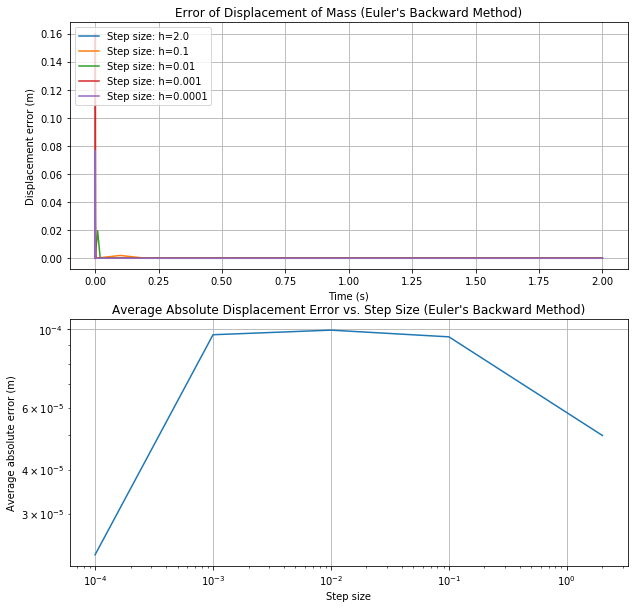

In [9]:
"""Error Quantification

Compare the error of Euler's Backward Method to the analytical solution.

This cell runs after the 'Setup Numerical Implementation' and
'Analytical Solution Solver' cells in the kernel.
"""


def plot_error(solver, title, h_values):
    # Configure subplot
    plt.subplot(2, 1, 1)
    plt.title(f'Error of Displacement of Mass ({title})')
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement error (m)')
    plt.grid(True)


    # Run the solver and plot
    avg_x_err = []
    for h in h_values:
        values = solver(f, x_i, t_i, t_f, h)
        values_exact = analytical_solution(f, x_i, t_i, t_f, h)
        x_err = values[1]-values_exact[1]
        avg_x_err.append(np.mean(np.abs(x_err)))
        plt.plot(values[0], x_err, label=f'Step size: h={h}')
    plt.legend(loc='upper left')

    # Plot average error vs. step size
    plt.subplot(2, 1, 2)
    plt.title(f'Average Absolute Displacement Error vs. Step Size ({title})')
    plt.xlabel('Step size')
    plt.ylabel('Average absolute error (m)')
    plt.grid(True)
    plt.loglog(h_values, avg_x_err)


# Setup plot
plt.figure(figsize=(10, 10))

# Solve and plot solutions
plot_error(backward_euler, "Euler's Backward Method", h_values_implicit)

# Show plot
plt.show()


We can see from the above plots of errors that for all step sizes, the Euler's
Backwards Method solutions behave as expected: the solutions remain in physical
bounds and both fast transients and slow dynamics are resolved correctly.

# Performance Analysis

## Accuracy vs. Computational Cost

The total number of time steps, average number of Newton-Raphson iterations
per time step, and total number of Newton-Raphson function evaluations are
shown in "Results & Analysis" for each solution at various step sizes. The
most accurate and also most computationally expensive solution, with the step
size $h=0.0001$, completed with 20,033 Newton-Raphson evaluations. Compared
to Euler's Forward Method, this is still significantly less expensive than
the 100,000 steps it would take to produce a stable solution for the same
two-second interval using Euler's Forward Method. However, increasing accuracy
further by decreasing step size will still further reduce efficiency, so
consideration must be taken with any method to choose a step size that offers
an appropriate balance of accuracy and efficiency.

| Method | Step Size | Is Stable? |
| :-: | :-: | :-: |
| Euler's Forward | 0.00002 | Yes |
| Euler's Forward | 0.1 | No |
| Euler's Backward | 0.0001 | Yes |
| Euler's Backward | 0.001 | Yes |
| Euler's Backward | 0.01 | Yes |
| Euler's Backward | 0.1 | Yes |
| Euler's Backward | 2.0 | Yes |

# Conclusions

In conclusion, implicit methods for solving differential equations (such as
Euler's Backward Method with Newton-Raphson) are much more stable and accurate
for solving stiff differential equations compared to explicit methods (such as
Euler's Forward Method). This makes implicit methods generally preferable for
solving stiff differential equations, although explicit methods can be more
efficient and consistent in performance for systems where they are stable
because they will always finish each time step in exactly one iteration,
whereas implicit methods may require a variable number of iterations for each
time step.